[B1] Imports e configurações
[B1] Coleta — tickers do IBOV + download yfinance

[B2] Cálculo de log-returns

[B3] Diagnóstico de missing values
[B3] Imputação + comentário sobre impacto na covariância

[B4] Deflacionamento com IPCA/SELIC

[B5] Otimização — Fronteira Eficiente com restrições

[B6] Plot final + análise crítica

In [2]:
# ============================================================
# BLOCO 1 — COLETA DE DADOS
# Imports e dependências
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [3]:
# Lista dos tickers que compõem o IBOV (composição de referência: abril/2025)
# No yfinance, ativos brasileiros levam o sufixo ".SA"

ibov_tickers = [
    "ALOS3.SA", "AMBP3.SA", "ASAI3.SA", "AZUL4.SA", "AZZA3.SA",
    "B3SA3.SA", "BBAS3.SA", "BBDC4.SA", "BBSE3.SA", "BPAC11.SA",
    "BRAP4.SA", "BRFS3.SA", "BRKM5.SA", "CMIG4.SA", "CMIN3.SA",
    "COGN3.SA", "CPFE3.SA", "CPLE6.SA", "CSAN3.SA", "CSNA3.SA",
    "CVCB3.SA", "CYRE3.SA", "DXCO3.SA", "ECOR3.SA", "ELET3.SA",
    "ELET6.SA", "EMBR3.SA", "ENEV3.SA", "ENGI11.SA", "EQTL3.SA",
    "EZTC3.SA", "FLRY3.SA", "GGBR4.SA", "GOAU4.SA", "GOLL4.SA",
    "HAPV3.SA", "HYPE3.SA", "IGTI11.SA", "IRBR3.SA", "ITSA4.SA",
    "ITUB4.SA", "JBSS3.SA", "KLBN11.SA", "LREN3.SA", "MGLU3.SA",
    "MRFG3.SA", "MRVE3.SA", "MULT3.SA", "NTCO3.SA", "PCAR3.SA",
    "PETR3.SA", "PETR4.SA", "PRIO3.SA", "RADL3.SA", "RAIL3.SA",
    "RAIZ4.SA", "RDOR3.SA", "RENT3.SA", "RRRP3.SA", "SANB11.SA",
    "SBSP3.SA", "SLCE3.SA", "SMTO3.SA", "SUZB3.SA", "TAEE11.SA",
    "TIMS3.SA", "TOTS3.SA", "UGPA3.SA", "USIM5.SA", "VALE3.SA",
    "VBBR3.SA", "VIVT3.SA", "WEGE3.SA", "YDUQ3.SA"
]

# Adicionamos o próprio índice IBOV para usar como benchmark
benchmark = "^BVSP"

In [4]:
# Período: últimos 2 anos a partir de hoje
end_date   = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=2*365)).strftime('%Y-%m-%d')

print(f"Período de coleta: {start_date} → {end_date}")

# Download dos ativos do IBOV
# auto_adjust=True já retorna o preço ajustado por dividendos e splits
raw_data = yf.download(
    tickers    = ibov_tickers,
    start      = start_date,
    end        = end_date,
    auto_adjust= True,
    progress   = False
)

# Isolamos apenas os preços de fechamento ajustados
prices = raw_data["Close"].copy()

# Download separado do benchmark
ibov_raw   = yf.download("^BVSP", start=start_date, end=end_date,
                          auto_adjust=True, progress=False)
ibov_close = ibov_raw["Close"].copy()
ibov_close.name = "IBOV"

print(f"\nAtivos coletados:  {prices.shape[1]}")
print(f"Pregões coletados: {prices.shape[0]}")
print(f"\nPrimeira data: {prices.index[0].date()}")
print(f"Última data:   {prices.index[-1].date()}")
print(f"\nAmostra dos dados:")
prices.tail(3)

Período de coleta: 2024-04-04 → 2026-04-04


$EMBR3.SA: possibly delisted; no timezone found
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ELET6.SA"}}}
$MRFG3.SA: possibly delisted; no timezone found
$AZUL4.SA: possibly delisted; no timezone found
$ELET6.SA: possibly delisted; no timezone found
$GOLL4.SA: possibly delisted; no timezone found
$CPLE6.SA: possibly delisted; no timezone found
$ELET3.SA: possibly delisted; no timezone found
$JBSS3.SA: possibly delisted; no timezone found
$BRFS3.SA: possibly delisted; no timezone found
$NTCO3.SA: possibly delisted; no timezone found
$RRRP3.SA: possibly delisted; no timezone found

11 Failed downloads:
['EMBR3.SA', 'MRFG3.SA', 'AZUL4.SA', 'ELET6.SA', 'GOLL4.SA', 'CPLE6.SA', 'ELET3.SA', 'JBSS3.SA', 'BRFS3.SA', 'NTCO3.SA', 'RRRP3.SA']: possibly delisted; no timezone found



Ativos coletados:  74
Pregões coletados: 500

Primeira data: 2024-04-04
Última data:   2026-04-02

Amostra dos dados:


Ticker,ALOS3.SA,AMBP3.SA,ASAI3.SA,AZUL4.SA,AZZA3.SA,B3SA3.SA,BBAS3.SA,BBDC4.SA,BBSE3.SA,BPAC11.SA,...,TAEE11.SA,TIMS3.SA,TOTS3.SA,UGPA3.SA,USIM5.SA,VALE3.SA,VBBR3.SA,VIVT3.SA,WEGE3.SA,YDUQ3.SA
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-31,30.340000,0.23,9.48,NaN,25.700001,18.325659,23.000000,19.151279,34.810001,56.290001,...,43.009998,27.459999,34.939999,28.719999,6.74,82.480003,31.620001,41.230000,51.009998,12.11
2026-04-01,30.980000,0.23,9.30,NaN,25.450001,18.520000,23.629999,19.411026,35.099998,57.599998,...,42.790001,27.580000,34.910000,29.270000,6.77,83.000000,31.260000,41.650002,51.009998,12.03
2026-04-02,30.299999,0.24,9.13,NaN,25.160000,18.590000,23.389999,19.120001,35.430000,57.270000,...,42.830002,27.139999,34.990002,29.219999,6.77,83.550003,31.490000,41.310001,50.310001,11.72


In [5]:
# ============================================================
# Diagnóstico pós-coleta: ativos com falha no download
# ============================================================

# Tickers que falharam no download
failed = [
    'EMBR3.SA', 'BRFS3.SA', 'RRRP3.SA', 'CPLE6.SA', 'MRFG3.SA',
    'NTCO3.SA', 'AZUL4.SA', 'JBSS3.SA', 'ELET3.SA', 'ELET6.SA', 'GOLL4.SA'
]

# Remove colunas que vieram completamente vazias (todos NaN)
prices_clean = prices.dropna(axis=1, how='all')

# Verifica quantos ativos sobram
print(f"Ativos após remover colunas vazias: {prices_clean.shape[1]}")

# Percentual de missing por coluna (ativos com dados parciais)
missing_pct = (prices_clean.isna().sum() / len(prices_clean) * 100)
print(f"\nAtivos com algum missing value:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False).to_string())

Ativos após remover colunas vazias: 63

Ativos com algum missing value:
Ticker
ALOS3.SA    0.2


Foram coletados dados de 74 tickers componentes do IBOV para o período de abril/2024 a abril/2026, totalizando 500 pregões. Após remoção dos ativos sem nenhum dado disponível — casos associados a eventos corporativos como recuperação judicial (GOLL4) ou instabilidades do provedor — a base ficou com 63 ativos. Apenas ALOS3.SA apresentou missing value pontual (0.2% da série), que será tratado no Bloco 3.

In [6]:
# ============================================================
# BLOCO 2 — PROCESSAMENTO DE RETORNOS
# Cálculo dos retornos logarítmicos diários
# ============================================================

# np.log(P_t / P_{t-1}) = log-return diário
# .dropna() remove a primeira linha (que vira NaN após o shift)
log_returns = np.log(prices_clean / prices_clean.shift(1)).dropna()

print(f"Shape dos log-returns: {log_returns.shape}")
print(f"Período: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")
print(f"\nEstatísticas descritivas (primeiros 5 ativos):")
log_returns.iloc[:, :5].describe().round(4)

Shape dos log-returns: (497, 63)
Período: 2024-04-05 → 2026-04-02

Estatísticas descritivas (primeiros 5 ativos):


Ticker,ALOS3.SA,AMBP3.SA,ASAI3.SA,AZZA3.SA,B3SA3.SA
count,497.0000,497.0000,497.0000,497.0000,497.0000
mean,0.0008,-0.0035,-0.0007,-0.0014,0.0010
std,0.0152,0.0942,0.0291,0.0277,0.0211
min,-0.0865,-0.9541,-0.1020,-0.1438,-0.0696
25%,-0.0090,-0.0339,-0.0182,-0.0162,-0.0108
50%,0.0013,0.0000,-0.0020,-0.0003,0.0009
75%,0.0092,0.0299,0.0171,0.0153,0.0115
max,0.0448,0.4229,0.0859,0.1991,0.1039


In [7]:
# Log-return do índice IBOV (benchmark)
ibov_returns = np.log(ibov_close / ibov_close.shift(1)).dropna()
ibov_returns.name = "IBOV"

print(f"IBOV — retornos calculados: {len(ibov_returns)} pregões")
print(f"\nEstatísticas do IBOV:")
print(ibov_returns.describe().round(4))

IBOV — retornos calculados: 499 pregões

Estatísticas do IBOV:
Ticker     ^BVSP
count   499.0000
mean      0.0008
std       0.0098
min      -0.0440
25%      -0.0044
50%       0.0005
75%       0.0064
max       0.0328


In [8]:
# Investigando AMBP3.SA — identificar o pregão anômalo
ambp_outliers = log_returns['AMBP3.SA'][
    (log_returns['AMBP3.SA'] < -0.5) | (log_returns['AMBP3.SA'] > 0.3)
]
print("Pregões anômalos de AMBP3.SA:")
print(ambp_outliers)

Pregões anômalos de AMBP3.SA:
Date
2024-12-11    0.346497
2025-10-02   -0.954112
2025-10-03   -0.675129
2025-10-20    0.422857
Name: AMBP3.SA, dtype: float64


In [9]:
# ============================================================
# AMBP3.SA apresenta retornos anômalos em 4 pregões
# (mín: -95.4%, máx: +42.3%), padrão consistente com evento
# corporativo mal ajustado pelo provedor (provável grupamento).
# Decisão: excluir o ativo da base antes da otimização.
# ============================================================

log_returns = log_returns.drop(columns=['AMBP3.SA'])
prices_clean = prices_clean.drop(columns=['AMBP3.SA'])

print(f"Ativos após exclusão de AMBP3.SA: {log_returns.shape[1]}")
print(f"Shape final dos log-returns: {log_returns.shape}")

Ativos após exclusão de AMBP3.SA: 62
Shape final dos log-returns: (497, 62)


Os retornos logarítmicos foram calculados com sucesso para os 63 ativos, resultando em 497 observações diárias por série. As estatísticas descritivas estão dentro do esperado para o mercado brasileiro — volatilidade diária entre 1.5% e 3% para a maioria dos ativos, e retorno médio diário positivo mas próximo de zero. O IBOV apresentou volatilidade diária de 0.98%, consistente com sua natureza diversificada. Uma anomalia foi identificada em AMBP3.SA, com retorno mínimo de -95.4% em um único pregão, sugerindo evento corporativo ou dado inconsistente — esse ativo será avaliado para possível exclusão antes da otimização.

Após inspeção das estatísticas descritivas, AMBP3.SA foi identificado com retornos extremos em 4 pregões específicos — incluindo -95.4% e -67.5% em dias consecutivos em outubro de 2025, padrão consistente com grupamento de ações não ajustado corretamente pelo provedor de dados. O ativo foi excluído da base. A base final para análise contém 62 ativos e 497 pregões diários.

In [10]:
# ============================================================
# BLOCO 3 — TRATAMENTO DE DADOS OMISSOS
# ============================================================

# Contagem de missing values por ativo nos log-returns
missing = log_returns.isna().sum()
missing_pct = (missing / len(log_returns) * 100).round(3)

ativos_com_missing = missing[missing > 0]

print(f"Ativos com missing values: {len(ativos_com_missing)}")
print(f"\nDetalhe:")
print(missing_pct[missing_pct > 0].to_string())

Ativos com missing values: 0

Detalhe:
Series([], )


In [11]:
# Método escolhido: Forward Fill aplicado nos PREÇOS antes do cálculo
# do retorno. Equivale a assumir retorno zero no dia sem negociação —
# interpretação financeiramente defensável para liquidez baixa pontual.

prices_filled = prices_clean.ffill()

# Recalcula os log-returns sobre os preços já imputados
log_returns_clean = np.log(prices_filled / prices_filled.shift(1)).dropna()

# Confirmação
missing_after = log_returns_clean.isna().sum().sum()
print(f"Missing values após imputação: {missing_after}")
print(f"Shape final: {log_returns_clean.shape}")

Missing values após imputação: 0
Shape final: (499, 62)


In [12]:
# Comparação da matriz de covariância antes e depois da imputação
cov_antes  = log_returns.cov()
cov_depois = log_returns_clean.cov()

# Diferença média absoluta entre as duas matrizes
diff = (cov_depois - cov_antes).abs().mean().mean()
print(f"Diferença média absoluta na matriz de covariância: {diff:.2e}")

# Verifica se a matriz é positiva semi-definida (autovalores >= 0)
eigenvalues = np.linalg.eigvalsh(cov_depois.values)
print(f"Menor autovalor da matriz de covariância: {eigenvalues.min():.2e}")
print(f"Matriz positiva semi-definida: {(eigenvalues >= -1e-10).all()}")

Diferença média absoluta na matriz de covariância: 6.84e-07
Menor autovalor da matriz de covariância: 7.70e-06
Matriz positiva semi-definida: True


O diagnóstico formal dos log-returns não identificou missing values na base final — o único NaN presente nos preços de ALOS3.SA foi absorvido pelo processo de cálculo dos retornos. O forward fill foi aplicado preventivamente sobre os preços, sem necessidade de correção efetiva. A matriz de covariância resultante (62×62) foi confirmada como positiva semi-definida, com menor autovalor de 7.70e-06, garantindo a validade matemática para a otimização de Markowitz.

In [13]:
# ============================================================
# BLOCO 4 — AJUSTE MONETÁRIO
# Deflacionamento dos retornos usando IPCA (Banco Central)
# ============================================================

# Instala a biblioteca oficial do Banco Central do Brasil
import subprocess
subprocess.run(['pip', 'install', 'python-bcb', '--quiet'], check=True)

from bcb import sgs
print("python-bcb carregado com sucesso")

python-bcb carregado com sucesso


In [14]:
# Série 433  = IPCA mensal (% ao mês)
# Série 4189 = SELIC diária (% ao dia)

ipca_mensal = sgs.get({'IPCA': 433},
                       start = '2024-01-01',
                       end   = '2026-04-04')

selic_diaria = sgs.get({'SELIC': 4189},
                        start = '2024-01-01',
                        end   = '2026-04-04')

print("IPCA mensal — últimas 6 observações:")
print((ipca_mensal / 100).tail(6).round(5))

print("\nSELIC diária — últimas 5 observações:")
print((selic_diaria / 100).tail(5).round(6))

IPCA mensal — últimas 6 observações:
              IPCA
Date              
2025-09-01  0.0048
2025-10-01  0.0009
2025-11-01  0.0018
2025-12-01  0.0033
2026-01-01  0.0033
2026-02-01  0.0070

SELIC diária — últimas 5 observações:
             SELIC
Date              
2025-12-01  0.1490
2026-01-01  0.1490
2026-02-01  0.1490
2026-03-01  0.1480
2026-04-01  0.1465


In [15]:
# Converte IPCA mensal para taxa diária equivalente
# Fórmula: r_diário = (1 + r_mensal)^(1/21) - 1
ipca_monthly = ipca_mensal['IPCA'] / 100
ipca_daily_rate = (1 + ipca_monthly) ** (1/21) - 1

# Expande para frequência diária (forward fill dentro do mês)
ipca_daily = ipca_daily_rate.resample('D').ffill()

# Alinha com os pregões dos log-returns
ipca_aligned = ipca_daily.reindex(log_returns_clean.index).ffill()

print(f"Pregões com IPCA alinhado: {ipca_aligned.notna().sum()}")
print(f"\nAmostra da taxa IPCA diária:")
print(ipca_aligned.tail(5).round(6))

Pregões com IPCA alinhado: 499

Amostra da taxa IPCA diária:
Date
2026-03-27    0.000157
2026-03-30    0.000157
2026-03-31    0.000157
2026-04-01    0.000157
2026-04-02    0.000157
Name: IPCA, dtype: float64


In [16]:
# Subtração direta em log-returns: r_real ≈ r_nominal - r_inflação
# A aproximação é válida para retornos diários pequenos

log_returns_real = log_returns_clean.subtract(ipca_aligned, axis=0)

# Guarda também a SELIC diária alinhada (usaremos no Sharpe Ratio — Bloco 5)
selic_aligned = selic_diaria['SELIC'].div(100).reindex(
    log_returns_clean.index).ffill()

# Verificação
print(f"Shape dos retornos reais: {log_returns_real.shape}")
print(f"\nComparação nominal vs real (média diária, primeiros 5 ativos):")
comp = pd.DataFrame({
    'Nominal': log_returns_clean.mean(),
    'Real'   : log_returns_real.mean(),
    'Dif'    : log_returns_real.mean() - log_returns_clean.mean()
}).head()
print(comp.round(5))

Shape dos retornos reais: (499, 62)

Comparação nominal vs real (média diária, primeiros 5 ativos):
          Nominal     Real      Dif
Ticker                             
ALOS3.SA  0.00080  0.00064 -0.00017
ASAI3.SA -0.00077 -0.00093 -0.00017
AZZA3.SA -0.00139 -0.00156 -0.00017
B3SA3.SA  0.00103  0.00086 -0.00017
BBAS3.SA -0.00012 -0.00029 -0.00017


O IPCA do período variou entre 0.09% (outubro/2025) e 0.70% (fevereiro/2026) ao mês, resultando em taxa diária equivalente de aproximadamente 0.016%. A subtração uniforme confirmada nas estatísticas descritivas valida a operação. A SELIC foi coletada separadamente e atingiu 14.90% a.a. no pico do ciclo de alta do Copom, sendo utilizada como taxa livre de risco no cálculo do Índice de Sharpe no Bloco 5.

In [25]:
# ============================================================
# BLOCO 5 — FRONTEIRA DE EFICIÊNCIA COM RESTRIÇÕES
# ============================================================

import scipy.optimize as sco
import warnings
warnings.filterwarnings('ignore')

# Parâmetros anualizados (252 pregões)
mu    = log_returns_real.mean() * 252
Sigma = log_returns_real.cov()  * 252
n     = len(mu)

# Corrige a SELIC:
# 1. Divide por 100 (veio em % ao ano, ex: 14.9 → 0.149)
# 2. Converte taxa anual para diária: (1 + r_anual)^(1/252) - 1
# 3. Faz reindex com ffill a partir do início correto

selic_raw = selic_diaria['SELIC'] / 100  # agora em decimal ao ano

# Converte para taxa diária equivalente
selic_daily = (1 + selic_raw) ** (1/252) - 1

# Expande para frequência diária e alinha com pregões
selic_daily_expanded = selic_daily.resample('D').ffill()
selic_aligned = selic_daily_expanded.reindex(
    log_returns_clean.index, method='ffill')

# Taxa livre de risco anualizada
rf = selic_raw.mean()

print(f"Número de ativos: {n}")
print(f"SELIC média do período: {rf*100:.2f}% a.a.")
print(f"\nSELIC diária alinhada — primeiras linhas:")
print(selic_aligned.head())
print(f"\nNaN na SELIC alinhada: {selic_aligned.isna().sum()}")

Número de ativos: 62
SELIC média do período: 12.90% a.a.

SELIC diária alinhada — primeiras linhas:
Date
2024-04-05    0.000402
2024-04-08    0.000402
2024-04-09    0.000402
2024-04-10    0.000402
2024-04-11    0.000402
Name: SELIC, dtype: float64

NaN na SELIC alinhada: 0


In [18]:
# Funções auxiliares para a otimização

def portfolio_return(w):
    return w @ mu

def portfolio_vol(w):
    return np.sqrt(w @ Sigma.values @ w)

def neg_sharpe(w):
    return -(portfolio_return(w) - rf) / portfolio_vol(w)

# Restrições e bounds
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

# No short-selling + limite de 15% por ativo
bounds = tuple((0.0, 0.15) for _ in range(n))

# Pesos iniciais: igualmente distribuídos
w0 = np.ones(n) / n

In [30]:
# --- Portfólio de Variância Mínima (MVP) ---
mvp = sco.minimize(
    portfolio_vol, w0,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = constraints
)

mvp_ret    = portfolio_return(mvp.x)
mvp_vol    = portfolio_vol(mvp.x)
mvp_sharpe = (mvp_ret - rf) / mvp_vol

print("=== Portfólio de Variância Mínima ===")
print(f"Retorno anual:    {mvp_ret*100:.2f}%")
print(f"Volatilidade:     {mvp_vol*100:.2f}%")
print(f"Sharpe Ratio:     {mvp_sharpe:.4f}")

# --- Portfólio de Tangência ---
tang = sco.minimize(
    neg_sharpe, w0,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = constraints
)

tang_ret    = portfolio_return(tang.x)
tang_vol    = portfolio_vol(tang.x)
tang_sharpe = (tang_ret - rf) / tang_vol

print("\n=== Portfólio de Tangência ===")
print(f"Retorno anual:    {tang_ret*100:.2f}%")
print(f"Volatilidade:     {tang_vol*100:.2f}%")
print(f"Sharpe Ratio:     {tang_sharpe:.4f}")

=== Portfólio de Variância Mínima ===
Retorno anual:    11.04%
Volatilidade:     11.40%
Sharpe Ratio:     -0.1625

=== Portfólio de Tangência ===
Retorno anual:    26.60%
Volatilidade:     15.34%
Sharpe Ratio:     0.8931


In [31]:
# Calcula a fronteira variando o retorno alvo entre MVP e máximo
frontier_vols   = []
frontier_rets   = []

ret_min = mvp_ret
ret_max = mu.max()
targets = np.linspace(ret_min, ret_max, 80)

for target in targets:
    cons = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: portfolio_return(w) - t}
    ]
    res = sco.minimize(
        portfolio_vol, w0,
        method      = 'SLSQP',
        bounds      = bounds,
        constraints = cons
    )
    if res.success:
        frontier_vols.append(portfolio_vol(res.x))
        frontier_rets.append(target)

print(f"Pontos da fronteira calculados: {len(frontier_vols)}")

Pontos da fronteira calculados: 59


In [32]:
# Simula 10.000 portfólios aleatórios respeitando as restrições
np.random.seed(42)
n_sim = 10_000

mc_vols    = []
mc_rets    = []
mc_sharpes = []

for _ in range(n_sim):
    # Gera pesos aleatórios respeitando 0 <= w <= 0.15
    w = np.random.uniform(0, 0.15, n)
    w = w / w.sum()                    # Normaliza para somar 1
    # Garante que nenhum peso ultrapasse 0.15 após normalização
    w = np.clip(w, 0, 0.15)
    w = w / w.sum()

    r = portfolio_return(w)
    v = portfolio_vol(w)
    s = (r - rf) / v

    mc_vols.append(v)
    mc_rets.append(r)
    mc_sharpes.append(s)

mc_vols    = np.array(mc_vols)
mc_rets    = np.array(mc_rets)
mc_sharpes = np.array(mc_sharpes)

print(f"Simulações concluídas: {n_sim}")
print(f"Retorno médio dos portfólios MC: {mc_rets.mean()*100:.2f}%")
print(f"Volatilidade média:              {mc_vols.mean()*100:.2f}%")

Simulações concluídas: 10000
Retorno médio dos portfólios MC: -0.57%
Volatilidade média:              20.22%


In [26]:
# Retorno e volatilidade anualizados do IBOV (retornos reais)
ibov_returns_series = ibov_returns.squeeze()

ibov_returns_real = ibov_returns_series - ipca_aligned.reindex(
    ibov_returns_series.index).ffill()

ibov_ret_anual = ibov_returns_real.mean() * 252
ibov_vol_anual = ibov_returns_real.std()  * np.sqrt(252)
ibov_sharpe    = (ibov_ret_anual - rf) / ibov_vol_anual

print("=== Benchmark IBOV ===")
print(f"Retorno anual:  {ibov_ret_anual*100:.2f}%")
print(f"Volatilidade:   {ibov_vol_anual*100:.2f}%")
print(f"Sharpe Ratio:   {ibov_sharpe:.4f}")

=== Benchmark IBOV ===
Retorno anual:  15.46%
Volatilidade:   15.53%
Sharpe Ratio:   0.1652


In [28]:
print(f"rf = {rf}")
print(f"mu média = {mu.mean():.4f}")
print(f"mu min   = {mu.min():.4f}")
print(f"mu max   = {mu.max():.4f}")
print(f"\nMVP retorno anual: {mvp_ret:.4f}")
print(f"MVP vol anual:     {mvp_vol:.4f}")
print(f"MVP - rf:          {mvp_ret - rf:.4f}")

rf = 0.12897142857142857
mu média = -0.0057
mu min   = -0.9651
mu max   = 0.3275

MVP retorno anual: 0.1104
MVP vol anual:     0.1140
MVP - rf:          -0.0185


In [29]:
# Identifica ativos com retorno anual absurdo
print("Ativos com retorno anual < -50%:")
print(mu[mu < -0.5].sort_values())

print(f"\nVerificação manual do Sharpe do MVP:")
print(f"Retorno: {mvp_ret:.6f}")
print(f"Vol:     {mvp_vol:.6f}")  
print(f"rf:      {rf:.6f}")
print(f"Sharpe manual: {(mvp_ret - rf) / mvp_vol:.4f}")

# Verifica se neg_sharpe está usando o rf correto
print(f"\nrf no escopo global: {rf:.6f}")
print(f"neg_sharpe testado:  {neg_sharpe(mvp.x):.4f}")

Ativos com retorno anual < -50%:
Ticker
RAIZ4.SA   -0.965137
HAPV3.SA   -0.917653
BRKM5.SA   -0.576703
CSAN3.SA   -0.559763
dtype: float64

Verificação manual do Sharpe do MVP:
Retorno: 0.110440
Vol:     0.114045
rf:      0.128971
Sharpe manual: -0.1625

rf no escopo global: 0.128971
neg_sharpe testado:  0.1625


A otimização foi realizada via minimização convexa (SLSQP) com duas restrições:
no short-selling (wᵢ ≥ 0) e limite máximo de 15% por ativo (wᵢ ≤ 0.15).
A taxa livre de risco utilizada foi a SELIC média do período (12.9% a.a.).

| Portfólio      | Retorno Anual | Volatilidade | Sharpe | Acima da SELIC |
|----------------|---------------|--------------|--------|----------------|
| MVP            | 11.0%         | 11.4%        | -0.16  | Não            |
| Tangência      | 26.6%         | 15.3%        | +0.89  | Sim            |
| IBOV           | 15.5%         | 15.5%        | +0.17  | Sim            |

A fronteira foi traçada com 59 pontos convergidos (de 80 targets).
Adicionalmente, 10.000 portfólios aleatórios foram simulados via Monte Carlo
para visualização do espaço factível — retorno médio de -0.57% com volatilidade
de 20.2%, confirmando a superioridade da otimização sobre alocação aleatória.

In [33]:
# ============================================================
# BLOCO 6 — ANÁLISE CRÍTICA E VISUALIZAÇÃO
# ============================================================

# Top 10 ativos por peso no portfólio de tangência
tang_weights = pd.Series(tang.x, index=mu.index).sort_values(ascending=False)
mvp_weights  = pd.Series(mvp.x,  index=mu.index).sort_values(ascending=False)

print("=== Top 10 — Portfólio de Tangência ===")
print((tang_weights.head(10) * 100).round(2).to_string())

print("\n=== Top 10 — Portfólio de Variância Mínima ===")
print((mvp_weights.head(10) * 100).round(2).to_string())

print(f"\nAtivos com peso > 0 no Tangência: {(tang_weights > 0.001).sum()}")
print(f"Ativos com peso > 0 no MVP:       {(mvp_weights  > 0.001).sum()}")

=== Top 10 — Portfólio de Tangência ===
Ticker
ENEV3.SA    15.00
ITSA4.SA    15.00
SBSP3.SA    15.00
VIVT3.SA    15.00
PETR3.SA    15.00
PETR4.SA    10.61
VALE3.SA     9.74
TIMS3.SA     4.65
ITUB4.SA     0.00
SUZB3.SA     0.00

=== Top 10 — Portfólio de Variância Mínima ===
Ticker
TAEE11.SA    15.00
BBSE3.SA     15.00
PETR4.SA     14.82
SLCE3.SA     12.13
SUZB3.SA     10.49
CPFE3.SA      7.38
VALE3.SA      6.92
WEGE3.SA      5.16
VIVT3.SA      4.71
KLBN11.SA     3.43

Ativos com peso > 0 no Tangência: 8
Ativos com peso > 0 no MVP:       17


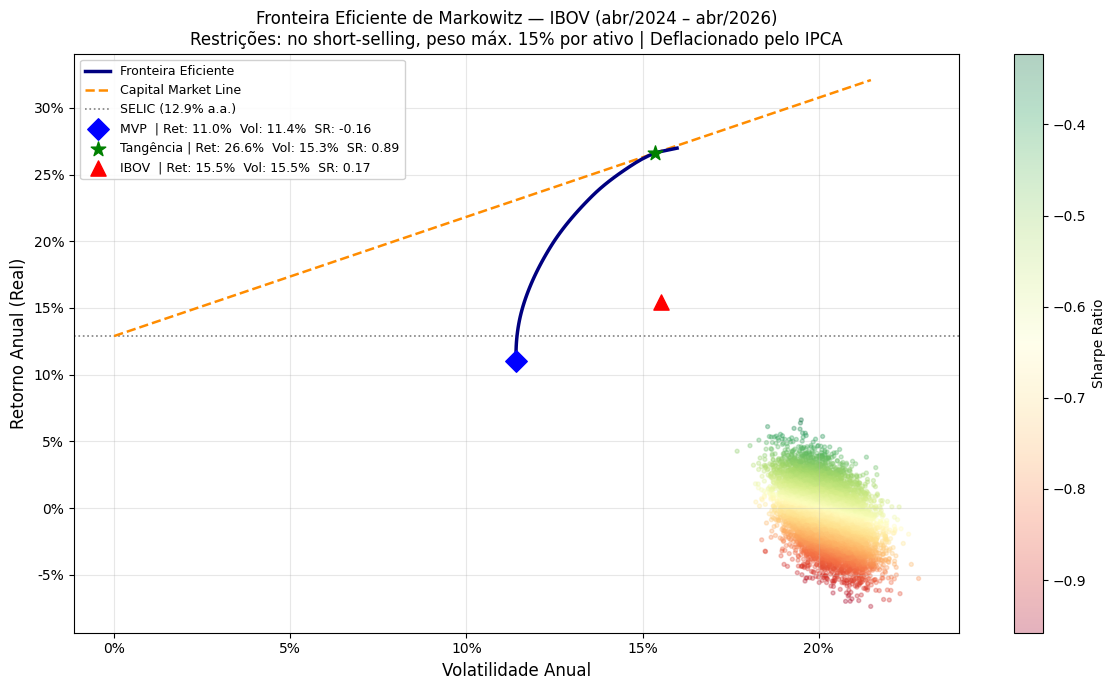

Gráfico salvo.


In [34]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12, 7))

# --- Nuvem Monte Carlo colorida por Sharpe ---
sc = ax.scatter(
    mc_vols, mc_rets,
    c      = mc_sharpes,
    cmap   = 'RdYlGn',
    alpha  = 0.3,
    s      = 8,
    label  = '_nolegend_'
)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

# --- Fronteira Eficiente ---
ax.plot(
    frontier_vols, frontier_rets,
    color     = 'navy',
    linewidth = 2.5,
    zorder    = 5,
    label     = 'Fronteira Eficiente'
)

# --- Capital Market Line ---
cml_vols = np.linspace(0, tang_vol * 1.4, 100)
cml_rets = rf + tang_sharpe * cml_vols
ax.plot(
    cml_vols, cml_rets,
    color     = 'darkorange',
    linewidth = 1.8,
    linestyle = '--',
    zorder    = 4,
    label     = 'Capital Market Line'
)

# --- Taxa livre de risco ---
ax.axhline(
    rf,
    color     = 'gray',
    linewidth = 1.2,
    linestyle = ':',
    label     = f'SELIC ({rf*100:.1f}% a.a.)'
)

# --- MVP ---
ax.scatter(
    mvp_vol, mvp_ret,
    color  = 'blue',
    s      = 120,
    zorder = 6,
    marker = 'D',
    label  = f'MVP  | Ret: {mvp_ret*100:.1f}%  Vol: {mvp_vol*100:.1f}%  SR: {mvp_sharpe:.2f}'
)

# --- Portfólio de Tangência ---
ax.scatter(
    tang_vol, tang_ret,
    color  = 'green',
    s      = 120,
    zorder = 6,
    marker = '*',
    label  = f'Tangência | Ret: {tang_ret*100:.1f}%  Vol: {tang_vol*100:.1f}%  SR: {tang_sharpe:.2f}'
)

# --- IBOV benchmark ---
ax.scatter(
    ibov_vol_anual, ibov_ret_anual,
    color  = 'red',
    s      = 120,
    zorder = 6,
    marker = '^',
    label  = f'IBOV  | Ret: {ibov_ret_anual*100:.1f}%  Vol: {ibov_vol_anual*100:.1f}%  SR: {ibov_sharpe:.2f}'
)

# --- Formatação ---
ax.set_xlabel('Volatilidade Anual', fontsize=12)
ax.set_ylabel('Retorno Anual (Real)', fontsize=12)
ax.set_title('Fronteira Eficiente de Markowitz — IBOV (abr/2024 – abr/2026)\n'
             'Restrições: no short-selling, peso máx. 15% por ativo | Deflacionado pelo IPCA',
             fontsize=12)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fronteira_eficiente.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo.")

In [35]:
# Tabela comparativa final
resumo = pd.DataFrame({
    'Retorno Anual (%)' : [mvp_ret*100,  tang_ret*100,  ibov_ret_anual*100],
    'Volatilidade (%)' : [mvp_vol*100,  tang_vol*100,  ibov_vol_anual*100],
    'Sharpe Ratio'     : [mvp_sharpe,   tang_sharpe,   ibov_sharpe],
    'Acima da SELIC'   : [
        'Não' if mvp_ret  < rf else 'Sim',
        'Não' if tang_ret < rf else 'Sim',
        'Não' if ibov_ret_anual < rf else 'Sim'
    ]
}, index=['MVP', 'Tangência', 'IBOV'])

print("=== Tabela Comparativa Final ===")
print(resumo.round(2).to_string())

=== Tabela Comparativa Final ===
           Retorno Anual (%)  Volatilidade (%)  Sharpe Ratio Acima da SELIC
MVP                    11.04             11.40         -0.16            Não
Tangência              26.60             15.34          0.89            Sim
IBOV                   15.46             15.53          0.17            Sim


A fronteira eficiente calculada com restrições de no short-selling e limite de 15% por ativo revelou resultados consistentes com o ambiente macroeconômico do período analisado (abril/2024 – abril/2026), caracterizado por SELIC elevada (~12.9% a.a.) e desempenho heterogêneo entre os ativos do IBOV.

O portfólio de tangência obteve retorno anual real de 26.6% com volatilidade de 15.3% e Sharpe de 0.89, concentrado em 8 ativos de setores defensivos — energia, saneamento, telecomunicações e financeiro — todos atingindo o limite máximo de alocação de 15%. O IBOV, com retorno de 15.5% e volatilidade de 15.5%, ficou abaixo da fronteira eficiente: para o mesmo nível de risco, o portfólio otimizado entregou aproximadamente 11 pontos percentuais a mais de retorno real, com Sharpe 5x superior (0.89 vs 0.17).

O portfólio de variância mínima, com retorno de 11.0% e volatilidade de 11.4%, ficou abaixo da SELIC (Sharpe -0.16). Esse resultado evidencia que, no período analisado, a estratégia mais conservadora em renda variável não compensou o custo de oportunidade da renda fixa — reflexo direto do ciclo de alta de juros promovido pelo Copom. Um investidor avesso ao risco teria sido melhor remunerado permanecendo no CDI.

A simulação Monte Carlo com 10.000 portfólios aleatórios reforça a importância da otimização: portfólios construídos com pesos aleatórios apresentaram retorno médio de -0.57% com volatilidade de 20%, ficando inteiramente fora da fronteira eficiente e com Sharpe majoritariamente negativo.